In [10]:
#Имепорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import PolynomialFeatures

# Задание: Борьба с переобучением через регуляризацию

**Описание данных:**
В файле `instrument_test_data.txt` содержатся результаты тестирования приборов. Каждая строка представляет один прибор:
- **Первый столбец**: Ошибка измерения в тесте 1
- **Второй столбец**: Ошибка измерения в тесте 2  
- **Третий столбец**: Состояние прибора (0 - исправен, 1 - неисправен)

**Условие прохождения теста:** Прибор считается исправным, если обе ошибки измерения близки к нулю.

**Цель:** Построить модель, которая по ошибкам измерений будет предсказывать состояние прибора.

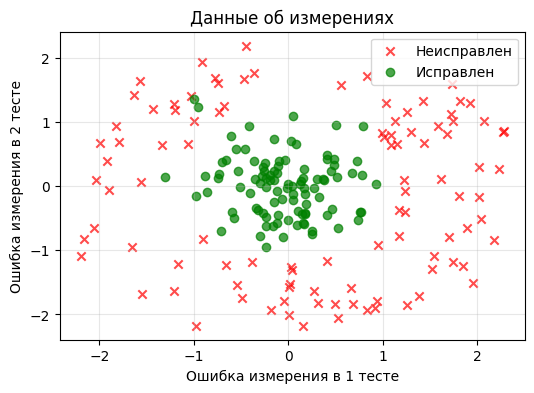

In [11]:
data = np.loadtxt('instrument_test_data.txt', delimiter=',')
X = data[:, :2]  # первые два столбца - ошибка измерения в 1 тесте, ошибка измерения в 2 тесте
y = data[:, 2]   # третий столбец - состояние прибора (0-исправлен или 1-неисправлен)

# Визуализируем данные
plt.figure(figsize=(6, 4))
admitted = y == 1
not_admitted = y == 0

plt.scatter(X[admitted, 0], X[admitted, 1], c='red', marker='x', label='Неисправлен', alpha=0.7)
plt.scatter(X[not_admitted, 0], X[not_admitted, 1], c='green', marker='o', label='Исправлен', alpha=0.7)

plt.xlabel('Ошибка измерения в 1 тесте')
plt.ylabel('Ошибка измерения в 2 тесте')
plt.title('Данные об измерениях')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 1: Создание сложной модели

1. **Добавьте полиномиальные признаки до 10-й степени**
   - Используйте `PolynomialFeatures(degree=10)`
   - Посмотрите, сколько признаков получилось
   - Объясните, почему теперь модель может строить сложные границы

2. **Обучите логистическую регрессию без регуляризации**
   - Используйте `LogisticRegression(C=100,  max_iter=1000)` (слабая регуляризация)
   - Постройте границу решений - код ниже
   - Что значит число 0.5 в строке в этом коде?
   
     `plt.contour(xx1, xx2, Z, levels=[0.5], colors='blue', linewidths=2)`
   - Обсудите: не слишком ли сложная граница? Есть ли переобучение?

### 2: Управление сложностью модели

3. **Экспериментируйте с параметром C**
   - `C=0.001` - очень сильная регуляризация
   - `C=1` - средняя регуляризация (значение по умолчанию)  
   - `C=100` - слабая регуляризация

   Для каждого значения:
   - Обучите модель
   - Постройте границу решений
   - Сравните точность и сложность границы

4. **Сделайте вывод, как регуляризация влияет на форму границы?**


In [12]:

#Пункт 1 - Добавьте полиномиальные признаки до 10-й степени
# Создаем полиномиальные признаки до 10-й степени
poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly = poly.fit_transform(X)

print(f"Исходная размерность: {X.shape}")
print(f"После добавления полиномиальных признаков: {X_poly.shape}")
print(f"Количество признаков: {X_poly.shape[1]}")

Исходная размерность: (200, 2)
После добавления полиномиальных признаков: (200, 65)
Количество признаков: 65


In [33]:
#Пункт 2 - Обучите логистическую регрессию без регуляризации
# Обучаем Logistic Regression на полиномиальных признаках
model_poly = LogisticRegression(C=100, max_iter=1000)
model_poly.fit(X_poly, y)

# Предсказания и оценка точности
y_pred_poly = model_poly.predict(X_poly)
accuracy_poly = accuracy_score(y, y_pred_poly)

print(f"Точность с полиномиальными признаками: {accuracy_poly:.3f} ({accuracy_poly*100:.1f}%)")

Точность с полиномиальными признаками: 1.000 (100.0%)


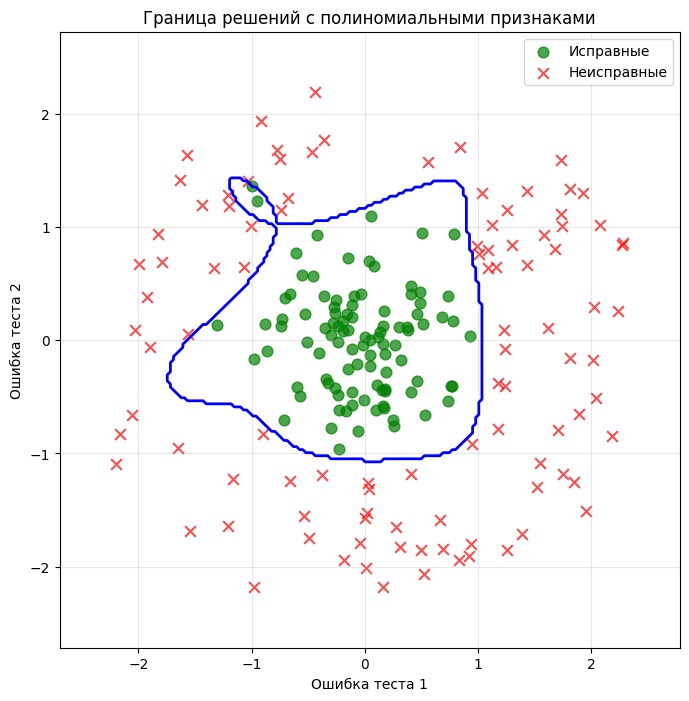

In [34]:
def plot_decision_boundary_poly(model, poly, X, y):
    """Визуализация границы решений для модели с полиномиальными признаками"""

    # Создаем сетку для построения границы
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                           np.linspace(x2_min, x2_max, 200))

    # Преобразуем сетку в полиномиальные признаки
    grid_points = np.c_[xx1.ravel(), xx2.ravel()]
    grid_poly = poly.transform(grid_points)

    # Предсказания для всей сетки
    Z = model.predict(grid_poly)
    Z = Z.reshape(xx1.shape)

    # Визуализация
    plt.figure(figsize=(8, 8))

    good = y == 0
    bad = y == 1

    plt.scatter(X[good, 0], X[good, 1], c='green', marker='o', label='Исправные', alpha=0.7, s=60)
    plt.scatter(X[bad, 0], X[bad, 1], c='red', marker='x', label='Неисправные', alpha=0.7, s=60)

    # Рисуем границу решений
    plt.contour(xx1, xx2, Z, levels=[0.5], colors='blue', linewidths=2)

    plt.xlabel('Ошибка теста 1')
    plt.ylabel('Ошибка теста 2')
    plt.title('Граница решений с полиномиальными признаками')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

# Строим границу решений
plot_decision_boundary_poly(model_poly, poly, X, y)

### 2: Управление сложностью модели

3. **Экспериментируйте с параметром C**
   - `C=0.001` - очень сильная регуляризация
   - `C=1` - средняя регуляризация (значение по умолчанию)  
   - `C=100` - слабая регуляризация

   Для каждого значения:
   - Обучите модель
   - Постройте границу решений
   - Сравните точность и сложность границы

4. **Сделайте вывод, как регуляризация влияет на форму границы?**


Точность с полиномиальными признаками: 0.880 (88.0%)
Точность с полиномиальными признаками: 0.980 (98.0%)
Точность с полиномиальными признаками: 1.000 (100.0%)


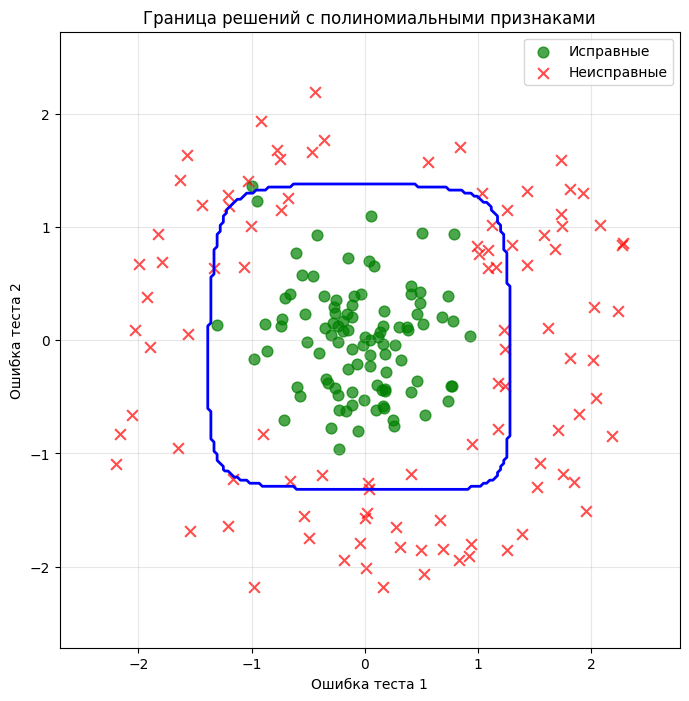

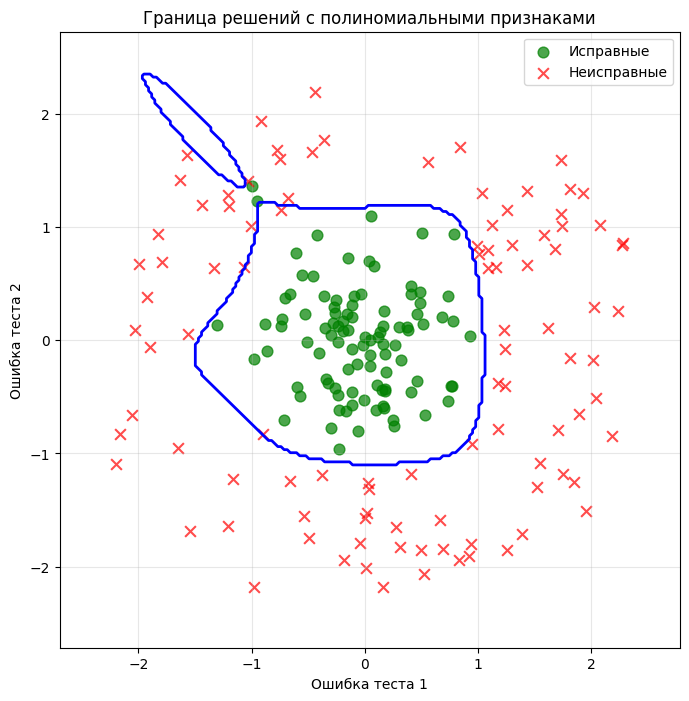

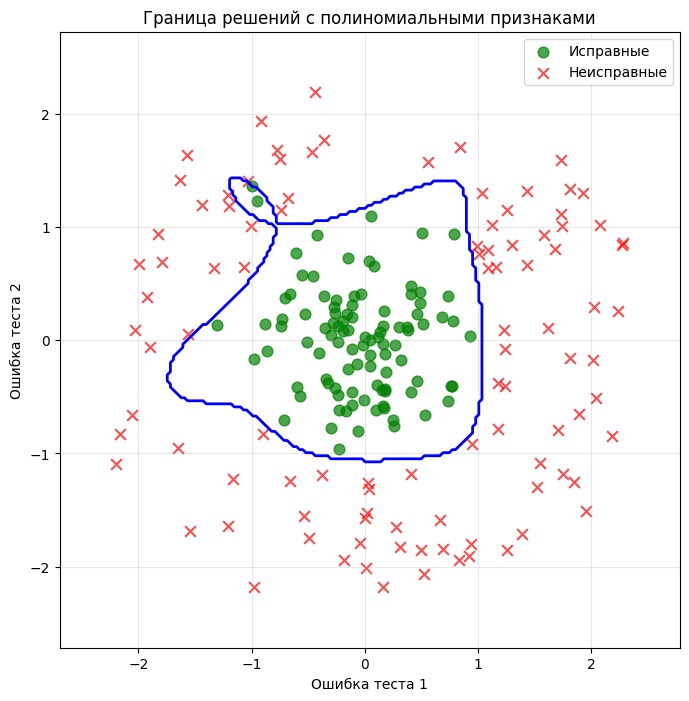

In [36]:
#Пункт 3 - Экспериментируйте с параметром C

# Обучаем Logistic Regression на полиномиальных признаках
model_poly_1 = LogisticRegression(C=0.001, max_iter=1000)
model_poly_2 = LogisticRegression(C=1, max_iter=1000)
model_poly_3 = LogisticRegression(C=100, max_iter=1000)
model_poly_1.fit(X_poly, y)
model_poly_2.fit(X_poly, y)
model_poly_3.fit(X_poly, y)

# Предсказания и оценка точности
y_pred_poly_1 = model_poly_1.predict(X_poly)
y_pred_poly_2 = model_poly_2.predict(X_poly)
y_pred_poly_3 = model_poly_3.predict(X_poly)

accuracy_poly_1 = accuracy_score(y, y_pred_poly_1)
accuracy_poly_2 = accuracy_score(y, y_pred_poly_2)
accuracy_poly_3 = accuracy_score(y, y_pred_poly_3)
print(f"Точность с полиномиальными признаками: {accuracy_poly_1:.3f} ({accuracy_poly_1*100:.1f}%)")
print(f"Точность с полиномиальными признаками: {accuracy_poly_2:.3f} ({accuracy_poly_2*100:.1f}%)")
print(f"Точность с полиномиальными признаками: {accuracy_poly_3:.3f} ({accuracy_poly_3*100:.1f}%)")

plot_decision_boundary_poly(model_poly_1, poly, X, y)
plot_decision_boundary_poly(model_poly_2, poly, X, y)
plot_decision_boundary_poly(model_poly_3, poly, X, y)

In [ ]:
#Пункт 4 - Сделайте вывод, как регуляризация влияет на форму границы?